**Assignment 5**

Implement and compare RNN, LSTM, and GRU models for sequence classification, and analyze their performance using appropriate evaluation metrics.

Dataset used: IMBD dataset (Tensorflow/Keras dataset)

In [ ]:
# Import libraries and install packages needed for modeling and plotting
!pip -q install scikit-learn
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM,GRU,Dense
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the IMDB dataset and pad sequences to a uniform length
max_features=10000
maxlen=200

(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=max_features)
x_train=pad_sequences(x_train,maxlen=maxlen)
x_test=pad_sequences(x_test,maxlen=maxlen)

In [ ]:
# Helper function to build RNN, LSTM, or GRU architectures dynamically
def build(kind):
    m=Sequential([Embedding(max_features,128,input_length=maxlen)])
    if kind=='RNN': m.add(SimpleRNN(64))
    elif kind=='LSTM': m.add(LSTM(64))
    else: m.add(GRU(64))
    m.add(Dense(1,activation='sigmoid'))
    m.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    return m

In [ ]:
# Train and evaluate RNN, LSTM, and GRU models on the dataset
results=[]
for kind in ['RNN','LSTM','GRU']:
    print(kind)
    model=build(kind)

    model.fit(x_train,y_train,epochs=3,batch_size=128,validation_split=0.2,verbose=1)
    pred=(model.predict(x_test)>0.5).astype(int).ravel()
    acc=accuracy_score(y_test,pred)
    p,r,f,_=precision_recall_fscore_support(y_test,pred,average='binary')
    print(confusion_matrix(y_test,pred))
    results.append([kind,acc,p,r,f])

RNN


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.6377 - loss: 0.6239 - val_accuracy: 0.7752 - val_loss: 0.4918
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8449 - loss: 0.3603 - val_accuracy: 0.8312 - val_loss: 0.4011
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9425 - loss: 0.1629 - val_accuracy: 0.8362 - val_loss: 0.4340
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
[[10211  2289]
 [ 1811 10689]]
LSTM
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7593 - loss: 0.4882 - val_accuracy: 0.8316 - val_loss: 0.3806
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8947 - loss: 0.2637 - val_accuracy: 0.8648 - val_loss: 0.3106
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9309 - loss: 0.1840 - val_accuracy: 0.8640 - val_loss: 0.3342
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[[10207  2293]
 [ 1186 11314]]
GRU
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7447 - loss: 0.4948 - val_accuracy: 0.8200 - val_loss: 0.4021
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8888 - loss: 0.2766 - val_accuracy: 0.8708 - val_loss: 0.3247
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9238 - loss: 0.2046 - val_accuracy: 0.8698 - val_loss: 0.3460
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[[11371  1129]
 [ 2513  9987]]


In [ ]:
# Collect evaluation metrics into a Pandas DataFrame and display
df=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1'])
print(df)

  Model  Accuracy  Precision   Recall        F1
0   RNN   0.83600   0.823625  0.85512  0.839077
1  LSTM   0.86084   0.831484  0.90512  0.866741
2   GRU   0.85432   0.898435  0.79896  0.845783


In [ ]:
# Display the consolidated performance metrics DataFrame
display(df)

,Model,Accuracy,Precision,Recall,F1
0,RNN,0.83600,0.823625,0.85512,0.839077
1,LSTM,0.86084,0.831484,0.90512,0.866741
2,GRU,0.85432,0.898435,0.79896,0.845783


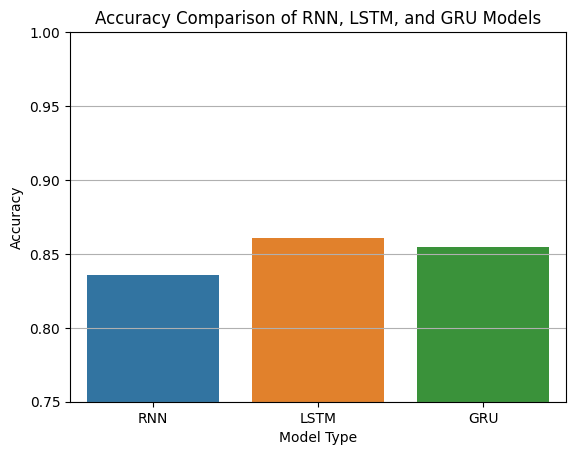

In [ ]:
# Visualize and compare accuracy across the three models
sns.barplot(x='Model', y='Accuracy', data=df, hue='Model')
plt.title('Accuracy Comparison of RNN, LSTM, and GRU Models')
plt.xlabel('Model Type')
plt.ylabel('Accuracy')
plt.ylim(0.75, 1.0)
plt.grid(axis='y')
plt.show()

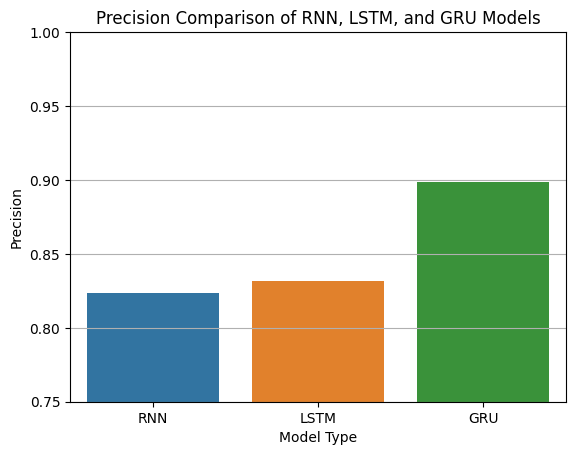

In [ ]:
# Visualize and compare precision across the three models
sns.barplot(x='Model', y='Precision', data=df, hue='Model')
plt.title('Precision Comparison of RNN, LSTM, and GRU Models')
plt.xlabel('Model Type')
plt.ylabel('Precision')
plt.ylim(0.75, 1.0)
plt.grid(axis='y')
plt.show()

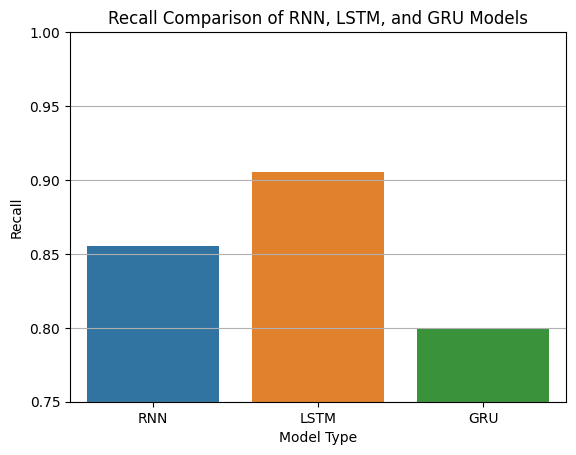

In [ ]:
# Visualize and compare recall across the three models
sns.barplot(x='Model', y='Recall', data=df, hue='Model')
plt.title('Recall Comparison of RNN, LSTM, and GRU Models')
plt.xlabel('Model Type')
plt.ylabel('Recall')
plt.ylim(0.75, 1.0)
plt.grid(axis='y')
plt.show()

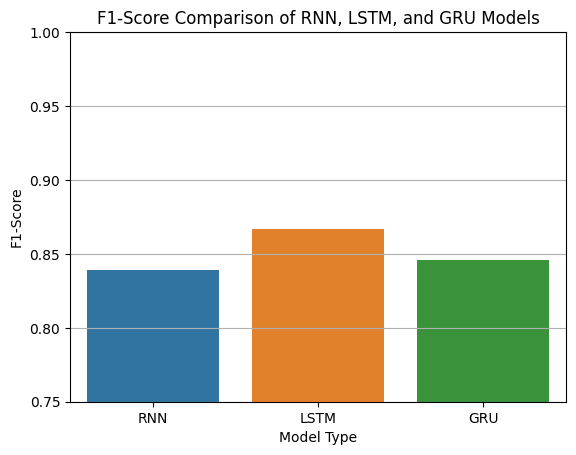

In [ ]:
# Visualize and compare F1-Score across the three models
sns.barplot(x='Model', y='F1', data=df, hue='Model')
plt.title('F1-Score Comparison of RNN, LSTM, and GRU Models')
plt.xlabel('Model Type')
plt.ylabel('F1-Score')
plt.ylim(0.75, 1.0)
plt.grid(axis='y')
plt.show()